# Standard Transformer vs Ternary Transformer: QAT, frozen inference и реальные 2-bit weights

Ноутбук сравнивает две архитектурно одинаковые decoder-only модели:

1. **Standard Transformer** — обычные `nn.Linear`;
2. **Ternary Transformer** — attention/FFN обучаются с тернарными весами
   \(\{-1, 0, +1\}\) через STE.

После обучения тернарная модель экспортируется в **три inference-представления**:

- `ternary_qat_fake` — исходная QAT-модель; каждый forward заново делает fake quantization;
- `ternary_frozen` — тернаризация выполняется **один раз**, после чего используется обычный `F.linear`;
- `ternary_packed2` — реальные тернарные коды хранятся по **2 бита на вес**:
  четыре веса в одном `uint8`. Полноточных мастер-весов для этих слоёв в deployment-модели нет;
- `ternary_torchao_int2` — дополнительный TorchAO `torch.int2` путь для проверки текущего
  low-bit API. Квантуются **только бывшие `TernaryLinear`**.

## Важное различие

`2-bit storage` и `bitwise GEMM` — не одно и то же.

`ternary_packed2` уже использует битовые `>>`, `<<`, `&`, `|` для упаковки/распаковки весов.
Reference-forward распаковывает веса перед `F.linear`, поэтому это честный compact storage,
но ещё не оптимальный GEMM.

Класс `PackedTernaryLinear` содержит точку подключения
`torch.ops.ternary_ops.linear_packed2`: когда будет добавлен fused Triton/CUDA/C++ kernel,
он сможет читать packed 2-bit веса напрямую без материализации матрицы весов.

> В актуальном TorchAO `IntxWeightOnlyConfig` поддерживает `torch.int2`, но weight-only
> workflow v2 использует `UNPACKED_TO_INT8`. Поэтому для **гарантированного физического
> хранения 2 бита/вес** ниже используется собственный `PackedTernaryLinear`, а TorchAO
> оставлен как дополнительный backend/API experiment.


## 1. Зависимости

Рекомендуются Python 3.10+, PyTorch 2.x и актуальный `torchao`.

```bash
pip install -U torch torchao transformers datasets pandas matplotlib tqdm
```

Используемые API TorchAO:

```python
from torchao.quantization import IntxWeightOnlyConfig, quantize_
```

Документация:

- https://docs.pytorch.org/ao/stable/eager_tutorials/first_quantization_example.html
- https://docs.pytorch.org/ao/stable/api_reference/generated/torchao.quantization.IntxWeightOnlyConfig.html

`torch.compile` особенно важен для quantized inference: TorchAO проектирует многие
низкоуровневые quantization primitives в расчёте на fusion/optimized kernels через Inductor.


In [1]:
import copy
import gc
import json
import math
import os
import random
import statistics
import time
import warnings
from contextlib import nullcontext
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Callable, Optional, Type

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import DatasetDict, load_dataset
from torch.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import AutoTokenizer

# TorchAO API менялся между версиями. Импортируем актуальный Intx API,
# но не делаем TorchAO обязательным для exact packed2 backend.
try:
    import torchao
    from torchao.quantization import IntxWeightOnlyConfig, quantize_
    from torchao.quantization.granularity import PerAxis
    from torchao.quantization.quant_primitives import MappingType

    TORCHAO_AVAILABLE = True
    TORCHAO_VERSION = getattr(torchao, "__version__", "unknown")
except Exception as exc:
    TORCHAO_AVAILABLE = False
    TORCHAO_VERSION = "unavailable"
    TORCHAO_IMPORT_ERROR = repr(exc)

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
torch.set_float32_matmul_precision("high")
torch.backends.cudnn.benchmark = True

print(f"PyTorch: {torch.__version__}")
print(f"TorchAO available: {TORCHAO_AVAILABLE}; version={TORCHAO_VERSION}")
if not TORCHAO_AVAILABLE:
    print(f"TorchAO import error: {TORCHAO_IMPORT_ERROR}")


/home/phil/GitHub/llm/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0807 13:36:05.744000 19584 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


PyTorch: 2.13.0+cu130
TorchAO available: True; version=0.18.0


In [2]:
@dataclass
class ExperimentConfig:
    # Данные и токенизатор
    dataset_name: str = "intexcp/russian-llm-training-dataset"
    tokenizer_name: str = "deepvk/RuModernBERT-base"
    tokenizer_revision: Optional[str] = "patched-tokenizer"
    input_column: str = "input"
    output_column: str = "output"
    validation_fraction: float = 0.05
    max_train_records: Optional[int] = 100_000
    max_validation_records: Optional[int] = 10_000
    tokenization_num_proc: int = min(8, os.cpu_count() or 1)
    tokenization_batch_size: int = 1_000
    max_text_tokens: int = 1_024

    # Модель
    sequence_length: int = 384
    d_model: int = 256
    n_heads: int = 4
    n_layers: int = 12
    d_ff: int = 1024
    dropout: float = 0.1
    tie_word_embeddings: bool = True

    # Обучение
    batch_size: int = 4
    num_workers: int = 0
    num_epochs: int = 5
    max_train_steps: Optional[int] = 4_000
    learning_rate: float = 2e-4
    weight_decay: float = 0.1
    warmup_ratio: float = 0.1
    grad_clip_norm: float = 1.0
    gradient_accumulation_steps: int = 2
    eval_every_steps: int = 500
    max_eval_batches: Optional[int] = 200
    log_every_steps: int = 25

    # Обучение / eager execution
    seed: int = 42
    use_amp: bool = True
    use_torch_compile: bool = True
    compile_mode: str = "default"

    # Deployment / inference
    compile_inference_models: bool = True
    packed_scale_dtype: str = "float16"  # float16 | bfloat16 | float32
    enable_torchao_int2_backend: bool = True
    torchao_scale_dtype: str = "float16"
    prefer_custom_packed_kernel: bool = True

    # Бенчмарк
    benchmark_warmup: int = 20
    benchmark_repeats: int = 100

    # Выходные файлы
    output_dir: str = "transformer_benchmark_outputs"


cfg = ExperimentConfig()
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)
print(json.dumps(asdict(cfg), ensure_ascii=False, indent=2))


{
  "dataset_name": "intexcp/russian-llm-training-dataset",
  "tokenizer_name": "deepvk/RuModernBERT-base",
  "tokenizer_revision": "patched-tokenizer",
  "input_column": "input",
  "output_column": "output",
  "validation_fraction": 0.05,
  "max_train_records": 100000,
  "max_validation_records": 10000,
  "tokenization_num_proc": 8,
  "tokenization_batch_size": 1000,
  "max_text_tokens": 1024,
  "sequence_length": 384,
  "d_model": 256,
  "n_heads": 4,
  "n_layers": 12,
  "d_ff": 1024,
  "dropout": 0.1,
  "tie_word_embeddings": true,
  "batch_size": 4,
  "num_workers": 0,
  "num_epochs": 5,
  "max_train_steps": 4000,
  "learning_rate": 0.0002,
  "weight_decay": 0.1,
  "warmup_ratio": 0.1,
  "grad_clip_norm": 1.0,
  "gradient_accumulation_steps": 2,
  "eval_every_steps": 500,
  "max_eval_batches": 200,
  "log_every_steps": 25,
  "seed": 42,
  "use_amp": true,
  "use_torch_compile": true,
  "compile_mode": "default",
  "compile_inference_models": true,
  "packed_scale_dtype": "float16",

## 2. Воспроизводимость и диагностика устройства

In [3]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def select_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


seed_everything(cfg.seed)
device = select_device()
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)

print(f"PyTorch: {torch.__version__}")
print(f"Устройство: {device}")
print(f"CUDA доступна: {torch.cuda.is_available()}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA runtime: {torch.version.cuda}")
    print(f"BF16 поддерживается: {torch.cuda.is_bf16_supported()}")
else:
    print("CUDA не используется. Скоростной бенчмарк будет отражать CPU/MPS, а не GPU.")

PyTorch: 2.13.0+cu130
Устройство: cuda
CUDA доступна: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
CUDA runtime: 13.0
BF16 поддерживается: True


## 3. Загрузка и разделение датасета

Разделение выполняется на уровне исходных записей, чтобы train и validation не содержали соседние фрагменты одного общего потока токенов.

In [4]:
raw = load_dataset(cfg.dataset_name)
print(raw)

if "train" not in raw:
    raise KeyError("В датасете отсутствует split 'train'.")

required_columns = {cfg.input_column, cfg.output_column}
missing_columns = required_columns - set(raw["train"].column_names)
if missing_columns:
    raise KeyError(
        f"В train отсутствуют колонки {sorted(missing_columns)}. "
        f"Доступны: {raw['train'].column_names}"
    )

if "validation" in raw:
    train_raw = raw["train"]
    validation_raw = raw["validation"]
elif "test" in raw:
    train_raw = raw["train"]
    validation_raw = raw["test"]
else:
    split = raw["train"].train_test_split(
        test_size=cfg.validation_fraction,
        seed=cfg.seed,
        shuffle=True,
    )
    train_raw = split["train"]
    validation_raw = split["test"]

if cfg.max_train_records is not None:
    train_raw = train_raw.select(range(min(cfg.max_train_records, len(train_raw))))
if cfg.max_validation_records is not None:
    validation_raw = validation_raw.select(
        range(min(cfg.max_validation_records, len(validation_raw)))
    )

print(f"Train-записей: {len(train_raw):,}")
print(f"Validation-записей: {len(validation_raw):,}")

DatasetDict({
    train: Dataset({
        features: ['input', 'think', 'output'],
        num_rows: 345889
    })
    test: Dataset({
        features: ['input', 'think', 'output'],
        num_rows: 3494
    })
})
Train-записей: 100,000
Validation-записей: 3,494


## 4. Токенизатор

`RuModernBERT` является encoder-токенизатором, но его словарь можно использовать для небольшого decoder-only эксперимента. Если отдельного EOS-токена нет, в качестве EOS используется `SEP`; при отсутствии обоих добавляется новый токен.

In [5]:
tokenizer_kwargs = {}
if cfg.tokenizer_revision is not None:
    tokenizer_kwargs["revision"] = cfg.tokenizer_revision

try:
    tokenizer = AutoTokenizer.from_pretrained(
        cfg.tokenizer_name,
        **tokenizer_kwargs,
    )
except Exception as exc:
    if cfg.tokenizer_revision is None:
        raise
    print(
        f"Не удалось загрузить revision={cfg.tokenizer_revision!r}: {exc}\n"
        "Повторная загрузка без указания revision."
    )
    tokenizer = AutoTokenizer.from_pretrained(cfg.tokenizer_name)

if tokenizer.eos_token_id is None:
    if tokenizer.sep_token_id is not None:
        tokenizer.eos_token = tokenizer.sep_token
    else:
        tokenizer.add_special_tokens({"eos_token": "<|eos|>"})

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

vocab_size = len(tokenizer)
print(f"Размер словаря: {vocab_size:,}")
print(f"EOS: {tokenizer.eos_token!r}, id={tokenizer.eos_token_id}")
print(f"PAD: {tokenizer.pad_token!r}, id={tokenizer.pad_token_id}")

Размер словаря: 50,368
EOS: '[SEP]', id=50282
PAD: '[PAD]', id=50283


## 5. Токенизация и формирование неперекрывающихся LM-блоков

Каждый блок содержит `sequence_length + 1` токен. Первые `sequence_length` токенов становятся входом, последние — сдвинутой на один токен целью.

В отличие от исходного `TokenDataset`, соседние примеры здесь не перекрываются на 127 из 128 токенов.

In [6]:
def format_examples(examples: dict) -> dict:
    texts = []
    eos = tokenizer.eos_token or ""

    for prompt, answer in zip(
        examples[cfg.input_column],
        examples[cfg.output_column],
    ):
        prompt = "" if prompt is None else str(prompt)
        answer = "" if answer is None else str(answer)
        texts.append(
            f"Вопрос:\n{prompt}\n\nОтвет:\n{answer}{eos}"
        )

    encoded = tokenizer(
        texts,
        add_special_tokens=False,
        truncation=True,
        max_length=cfg.max_text_tokens,
        padding=False,
        return_attention_mask=False,
    )
    return {"input_ids": encoded["input_ids"]}


def group_into_causal_blocks(examples: dict) -> dict:
    block_with_target = cfg.sequence_length + 1
    concatenated = []
    for token_ids in examples["input_ids"]:
        concatenated.extend(token_ids)

    usable_length = (len(concatenated) // block_with_target) * block_with_target
    concatenated = concatenated[:usable_length]

    blocks = [
        concatenated[start:start + block_with_target]
        for start in range(0, usable_length, block_with_target)
    ]

    return {
        "input_ids": [block[:-1] for block in blocks],
        "labels": [block[1:] for block in blocks],
    }


def prepare_split(dataset, split_name: str):
    tokenized = dataset.map(
        format_examples,
        batched=True,
        batch_size=cfg.tokenization_batch_size,
        num_proc=cfg.tokenization_num_proc,
        remove_columns=dataset.column_names,
        desc=f"Токенизация {split_name}",
    )

    grouped = tokenized.map(
        group_into_causal_blocks,
        batched=True,
        batch_size=cfg.tokenization_batch_size,
        num_proc=1,
        remove_columns=tokenized.column_names,
        desc=f"Формирование блоков {split_name}",
    )
    grouped.set_format(type="torch", columns=["input_ids", "labels"])
    return grouped


train_dataset = prepare_split(train_raw, "train")
validation_dataset = prepare_split(validation_raw, "validation")

if len(train_dataset) == 0 or len(validation_dataset) == 0:
    raise RuntimeError(
        "После группировки получился пустой split. Увеличьте число записей "
        "или уменьшите sequence_length."
    )

print(f"Train-блоков: {len(train_dataset):,}")
print(f"Validation-блоков: {len(validation_dataset):,}")
print(f"Форма одного входа: {tuple(train_dataset[0]['input_ids'].shape)}")

Train-блоков: 158,391
Validation-блоков: 5,532
Форма одного входа: (384,)


In [7]:
def make_dataloaders(seed: int) -> tuple[DataLoader, DataLoader]:
    generator = torch.Generator()
    generator.manual_seed(seed)

    common_kwargs = {
        "batch_size": cfg.batch_size,
        "num_workers": cfg.num_workers,
        "pin_memory": device.type == "cuda",
        "persistent_workers": cfg.num_workers > 0,
    }

    train_loader = DataLoader(
        train_dataset,
        shuffle=True,
        drop_last=True,
        generator=generator,
        **common_kwargs,
    )
    validation_loader = DataLoader(
        validation_dataset,
        shuffle=False,
        drop_last=False,
        **common_kwargs,
    )
    return train_loader, validation_loader


train_loader_check, validation_loader_check = make_dataloaders(cfg.seed)
first_batch = next(iter(train_loader_check))
print({key: tuple(value.shape) for key, value in first_batch.items()})

{'input_ids': (4, 384), 'labels': (4, 384)}


## 6. Тернарный линейный слой

Для каждой выходной строки весов вычисляется масштаб

\[
\alpha_i = \operatorname{mean}_j |W_{ij}|.
\]

Затем мастер-веса квантуются как

\[
Q(W_{ij}) = \operatorname{clip}\!\left(\operatorname{round}\left(\frac{W_{ij}}{\alpha_i}\right), -1, 1\right)\alpha_i.
\]

В backward-pass используется straight-through estimator:

```python
W_q = W + (Q(W) - W).detach()
```

Поэтому оптимизатор обновляет полноточные мастер-веса, а forward использует их тернарное приближение.

In [8]:
def ternary_codes_and_scale(
    weight: torch.Tensor,
    eps: float = 1e-5,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    QAT representation:
        weight ~= scale[row] * code
        code in {-1, 0, +1}

    Scale is per output channel / row.
    """
    scale = weight.detach().abs().mean(dim=1, keepdim=True).clamp_min(eps)
    codes = torch.clamp(torch.round(weight / scale), min=-1, max=1)
    return codes, scale


def ternary_quantize_per_output_channel(
    weight: torch.Tensor,
    eps: float = 1e-5,
) -> tuple[torch.Tensor, torch.Tensor]:
    codes, scale = ternary_codes_and_scale(weight, eps=eps)
    return codes * scale, codes


class TernaryLinear(nn.Linear):
    """
    Training/QAT layer.

    Master weights remain floating point so AdamW can optimize them.
    Every training forward uses ternary fake quantization + STE.
    Do NOT use this class as the final compact inference representation.
    """

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        quantized, _ = ternary_quantize_per_output_channel(self.weight)
        ste_weight = self.weight + (quantized - self.weight).detach()
        return F.linear(x, ste_weight, self.bias)


## 7. Единая архитектура decoder-only трансформера

Обе модели используют один и тот же код attention, residual connections, LayerNorm, FFN, позиционные embedding и LM-head. Единственное отличие — `nn.Linear` против `TernaryLinear` внутри attention и FFN.

In [9]:
@dataclass
class ModelConfig:
    vocab_size: int
    max_seq_len: int
    d_model: int
    n_heads: int
    n_layers: int
    d_ff: int
    dropout: float
    tie_word_embeddings: bool = True


class CausalSelfAttention(nn.Module):
    def __init__(
        self,
        model_cfg: ModelConfig,
        linear_cls: Type[nn.Linear],
    ) -> None:
        super().__init__()
        if model_cfg.d_model % model_cfg.n_heads != 0:
            raise ValueError("d_model должен делиться на n_heads без остатка")

        self.n_heads = model_cfg.n_heads
        self.head_dim = model_cfg.d_model // model_cfg.n_heads
        self.dropout = model_cfg.dropout

        self.q_proj = linear_cls(model_cfg.d_model, model_cfg.d_model, bias=False)
        self.k_proj = linear_cls(model_cfg.d_model, model_cfg.d_model, bias=False)
        self.v_proj = linear_cls(model_cfg.d_model, model_cfg.d_model, bias=False)
        self.out_proj = linear_cls(model_cfg.d_model, model_cfg.d_model, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len, d_model = x.shape

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        q = q.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)

        attention = F.scaled_dot_product_attention(
            q,
            k,
            v,
            attn_mask=None,
            dropout_p=self.dropout if self.training else 0.0,
            is_causal=True,
        )

        attention = attention.transpose(1, 2).contiguous().view(
            batch_size,
            seq_len,
            d_model,
        )
        return self.out_proj(attention)


class DecoderBlock(nn.Module):
    def __init__(
        self,
        model_cfg: ModelConfig,
        linear_cls: Type[nn.Linear],
    ) -> None:
        super().__init__()
        self.ln_attn = nn.LayerNorm(model_cfg.d_model)
        self.attn = CausalSelfAttention(model_cfg, linear_cls)
        self.ln_ffn = nn.LayerNorm(model_cfg.d_model)
        self.ffn = nn.Sequential(
            linear_cls(model_cfg.d_model, model_cfg.d_ff, bias=False),
            nn.GELU(),
            linear_cls(model_cfg.d_ff, model_cfg.d_model, bias=False),
            nn.Dropout(model_cfg.dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln_attn(x))
        x = x + self.ffn(self.ln_ffn(x))
        return x


class DecoderOnlyTransformer(nn.Module):
    def __init__(
        self,
        model_cfg: ModelConfig,
        linear_cls: Type[nn.Linear] = nn.Linear,
    ) -> None:
        super().__init__()
        self.config = model_cfg
        self.token_embedding = nn.Embedding(model_cfg.vocab_size, model_cfg.d_model)
        self.position_embedding = nn.Embedding(model_cfg.max_seq_len, model_cfg.d_model)
        self.embedding_dropout = nn.Dropout(model_cfg.dropout)

        self.blocks = nn.ModuleList(
            DecoderBlock(model_cfg, linear_cls)
            for _ in range(model_cfg.n_layers)
        )
        self.final_norm = nn.LayerNorm(model_cfg.d_model)
        self.lm_head = nn.Linear(model_cfg.d_model, model_cfg.vocab_size, bias=False)

        self.apply(self._initialize_weights)

        if model_cfg.tie_word_embeddings:
            self.lm_head.weight = self.token_embedding.weight

    @staticmethod
    def _initialize_weights(module: nn.Module) -> None:
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                nn.init.zeros_(module.bias)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len = input_ids.shape
        if seq_len > self.config.max_seq_len:
            raise ValueError(
                f"Длина {seq_len} превышает max_seq_len={self.config.max_seq_len}"
            )

        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0)
        x = self.token_embedding(input_ids) + self.position_embedding(positions)
        x = self.embedding_dropout(x)

        for block in self.blocks:
            x = block(x)

        x = self.final_norm(x)
        return self.lm_head(x)

## 8. Создание моделей с одинаковой инициализацией

In [10]:
model_cfg = ModelConfig(
    vocab_size=vocab_size,
    max_seq_len=cfg.sequence_length,
    d_model=cfg.d_model,
    n_heads=cfg.n_heads,
    n_layers=cfg.n_layers,
    d_ff=cfg.d_ff,
    dropout=cfg.dropout,
    tie_word_embeddings=cfg.tie_word_embeddings,
)


def build_model(linear_cls: Type[nn.Linear]) -> DecoderOnlyTransformer:
    # Один и тот же seed перед созданием каждой модели обеспечивает
    # одинаковые исходные полноточные мастер-веса.
    seed_everything(cfg.seed)
    return DecoderOnlyTransformer(model_cfg, linear_cls=linear_cls)


standard_model = build_model(nn.Linear)
ternary_model = build_model(TernaryLinear)

standard_state = standard_model.state_dict()
ternary_state = ternary_model.state_dict()
common_keys = standard_state.keys() & ternary_state.keys()
initialization_matches = all(
    torch.equal(standard_state[key], ternary_state[key])
    for key in common_keys
)

print(f"Одинаковая инициализация общих параметров: {initialization_matches}")
print(f"Standard parameters: {sum(p.numel() for p in standard_model.parameters()):,}")
print(f"Ternary parameters:  {sum(p.numel() for p in ternary_model.parameters()):,}")

if not initialization_matches:
    raise RuntimeError("Начальные веса моделей не совпадают.")

Одинаковая инициализация общих параметров: True
Standard parameters: 22,442,496
Ternary parameters:  22,442,496


In [11]:
@torch.no_grad()
def ternary_code_statistics(model: nn.Module) -> pd.DataFrame:
    rows = []
    for name, module in model.named_modules():
        if not isinstance(module, TernaryLinear):
            continue

        _, codes = ternary_quantize_per_output_channel(module.weight)
        total = codes.numel()
        rows.append(
            {
                "layer": name,
                "weights": total,
                "-1_%": 100.0 * (codes == -1).sum().item() / total,
                "0_%": 100.0 * (codes == 0).sum().item() / total,
                "+1_%": 100.0 * (codes == 1).sum().item() / total,
            }
        )
    return pd.DataFrame(rows)


initial_ternary_stats = ternary_code_statistics(ternary_model)
display(initial_ternary_stats)

if not initial_ternary_stats.empty and initial_ternary_stats["0_%"].eq(100.0).all():
    raise RuntimeError("Все тернарные веса обнулились — квантизация настроена неверно.")

,layer,weights,-1_%,0_%,+1_%
0,blocks.0.attn.q_proj,65536,34.495544,30.799866,34.704590
1,blocks.0.attn.k_proj,65536,34.538269,30.912781,34.548950
2,blocks.0.attn.v_proj,65536,34.333801,31.047058,34.619141
3,blocks.0.attn.out_proj,65536,34.715271,30.828857,34.455872
4,blocks.0.ffn.0,262144,34.407425,30.965805,34.626770
...,...,...,...,...,...
67,blocks.11.attn.k_proj,65536,34.515381,30.900574,34.584045
68,blocks.11.attn.v_proj,65536,34.725952,30.772400,34.501648
69,blocks.11.attn.out_proj,65536,34.428406,30.862427,34.709167
70,blocks.11.ffn.0,262144,34.471512,30.990219,34.538269


## 9. Функции обучения и оценки

In [12]:
def amp_settings() -> tuple[bool, Optional[torch.dtype]]:
    if not cfg.use_amp or device.type != "cuda":
        return False, None
    if torch.cuda.is_bf16_supported():
        return True, torch.bfloat16
    return True, torch.float16


AMP_ENABLED, AMP_DTYPE = amp_settings()
USE_GRAD_SCALER = AMP_ENABLED and AMP_DTYPE == torch.float16
print(f"AMP: {AMP_ENABLED}, dtype={AMP_DTYPE}, GradScaler={USE_GRAD_SCALER}")


def autocast_context():
    if not AMP_ENABLED:
        return nullcontext()
    return autocast(
        device_type=device.type,
        dtype=AMP_DTYPE,
        enabled=True,
    )


def causal_lm_loss(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    return F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        labels.reshape(-1),
    )


def unwrap_model(model: nn.Module) -> nn.Module:
    return model._orig_mod if hasattr(model, "_orig_mod") else model


def clone_state_dict_to_cpu(model: nn.Module) -> dict[str, torch.Tensor]:
    return {
        key: value.detach().cpu().clone()
        for key, value in unwrap_model(model).state_dict().items()
    }


def build_scheduler(
    optimizer: torch.optim.Optimizer,
    total_steps: int,
) -> LambdaLR:
    warmup_steps = max(1, int(total_steps * cfg.warmup_ratio))

    def lr_lambda(step: int) -> float:
        if step < warmup_steps:
            return float(step + 1) / float(warmup_steps)

        decay_steps = max(1, total_steps - warmup_steps)
        progress = min(1.0, (step - warmup_steps) / decay_steps)
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    return LambdaLR(optimizer, lr_lambda)

AMP: True, dtype=torch.bfloat16, GradScaler=False


In [13]:
@torch.inference_mode()
def evaluate_model(
    model: nn.Module,
    validation_loader: DataLoader,
    max_batches: Optional[int] = None,
) -> dict[str, float]:
    model.eval()

    loss_sum = 0.0
    correct_tokens = 0
    token_count = 0
    processed_batches = 0

    for batch_index, batch in enumerate(validation_loader):
        if max_batches is not None and batch_index >= max_batches:
            break

        input_ids = batch["input_ids"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        with autocast_context():
            logits = model(input_ids)
            loss = causal_lm_loss(logits, labels)

        tokens = labels.numel()
        loss_sum += loss.item() * tokens
        correct_tokens += (logits.argmax(dim=-1) == labels).sum().item()
        token_count += tokens
        processed_batches += 1

    if token_count == 0:
        raise RuntimeError("Валидационный loader не вернул ни одного токена.")

    mean_loss = loss_sum / token_count
    perplexity = math.exp(min(mean_loss, 20.0))

    return {
        "val_loss": mean_loss,
        "perplexity": perplexity,
        "token_accuracy": correct_tokens / token_count,
        "eval_tokens": token_count,
        "eval_batches": processed_batches,
    }

In [14]:
def train_model(
    model: nn.Module,
    model_name: str,
) -> tuple[nn.Module, pd.DataFrame, dict[str, float]]:
    train_loader, validation_loader = make_dataloaders(cfg.seed)

    model = model.to(device)
    if cfg.use_torch_compile:
        model = torch.compile(model, mode=cfg.compile_mode)

    optimizer = AdamW(
        model.parameters(),
        lr=cfg.learning_rate,
        weight_decay=cfg.weight_decay,
        fused=True,
    )

    steps_per_epoch = math.ceil(
        len(train_loader) / cfg.gradient_accumulation_steps
    )
    natural_total_steps = cfg.num_epochs * steps_per_epoch
    total_steps = (
        min(cfg.max_train_steps, natural_total_steps)
        if cfg.max_train_steps is not None
        else natural_total_steps
    )
    if total_steps <= 0:
        raise RuntimeError("Число training steps должно быть положительным.")

    scheduler = build_scheduler(optimizer, total_steps)
    scaler = GradScaler("cuda", enabled=USE_GRAD_SCALER)

    history: list[dict[str, float]] = []
    best_state = clone_state_dict_to_cpu(model)
    best_val_loss = float("inf")

    global_step = 0
    optimizer.zero_grad(set_to_none=True)
    train_started = time.perf_counter()
    processed_train_tokens = 0
    running_loss_sum = 0.0
    running_token_count = 0

    progress = tqdm(total=total_steps, desc=f"Training {model_name}")

    for epoch in range(1, cfg.num_epochs + 1):
        model.train()

        for micro_step, batch in enumerate(train_loader, start=1):
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            labels = batch["labels"].to(device, non_blocking=True)

            with autocast_context():
                logits = model(input_ids)
                raw_loss = causal_lm_loss(logits, labels)
                loss = raw_loss / cfg.gradient_accumulation_steps

            if USE_GRAD_SCALER:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            tokens = labels.numel()
            processed_train_tokens += tokens
            running_loss_sum += raw_loss.item() * tokens
            running_token_count += tokens

            should_update = micro_step % cfg.gradient_accumulation_steps == 0
            if not should_update:
                continue

            if USE_GRAD_SCALER:
                scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)

            if USE_GRAD_SCALER:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()

            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
            global_step += 1
            progress.update(1)

            current_train_loss = running_loss_sum / max(1, running_token_count)
            progress.set_postfix(
                loss=f"{current_train_loss:.4f}",
                lr=f"{scheduler.get_last_lr()[0]:.2e}",
            )

            should_evaluate = (
                global_step % cfg.eval_every_steps == 0
                or global_step == total_steps
            )

            if should_evaluate:
                metrics = evaluate_model(
                    model,
                    validation_loader,
                    max_batches=cfg.max_eval_batches,
                )
                elapsed = time.perf_counter() - train_started
                row = {
                    "model": model_name,
                    "step": global_step,
                    "epoch": epoch,
                    "train_loss": current_train_loss,
                    "learning_rate": scheduler.get_last_lr()[0],
                    "train_tokens_per_second": processed_train_tokens / elapsed,
                    **metrics,
                }
                history.append(row)

                print(
                    f"\n{model_name} step={global_step}: "
                    f"train_loss={current_train_loss:.4f}, "
                    f"val_loss={metrics['val_loss']:.4f}, "
                    f"ppl={metrics['perplexity']:.2f}, "
                    f"acc={metrics['token_accuracy']:.2%}"
                )

                if metrics["val_loss"] < best_val_loss:
                    best_val_loss = metrics["val_loss"]
                    best_state = clone_state_dict_to_cpu(model)

                model.train()
                running_loss_sum = 0.0
                running_token_count = 0

            if global_step >= total_steps:
                break

        if global_step >= total_steps:
            break

    progress.close()
    total_training_seconds = time.perf_counter() - train_started

    base_model = unwrap_model(model)
    base_model.load_state_dict(best_state)
    base_model.to(device)

    final_metrics = evaluate_model(
        base_model,
        validation_loader,
        max_batches=cfg.max_eval_batches,
    )
    final_metrics.update(
        {
            "model": model_name,
            "training_seconds": total_training_seconds,
            "training_steps": global_step,
            "processed_train_tokens": processed_train_tokens,
            "overall_train_tokens_per_second": (
                processed_train_tokens / total_training_seconds
            ),
        }
    )

    checkpoint = {
        "experiment_config": asdict(cfg),
        "model_config": asdict(model_cfg),
        "model_name": model_name,
        "state_dict": best_state,
        "metrics": final_metrics,
    }
    checkpoint_path = Path(cfg.output_dir) / f"{model_name}_best.pt"
    torch.save(checkpoint, checkpoint_path)
    print(f"Checkpoint сохранён: {checkpoint_path}")

    return base_model, pd.DataFrame(history), final_metrics

## 10. Обучение стандартной модели

In [15]:
standard_model, standard_history, standard_metrics = train_model(
    standard_model,
    model_name="standard",
)
display(pd.DataFrame([standard_metrics]))

Training standard:  13%|█▎        | 502/4000 [00:25<16:58,  3.44it/s, loss=7.1712, lr=2.00e-04] 


standard step=500: train_loss=8.6728, val_loss=7.5196, ppl=1843.81, acc=10.87%


Training standard:  25%|██▌       | 1003/4000 [00:46<09:14,  5.41it/s, loss=6.7945, lr=1.86e-04]


standard step=1000: train_loss=7.0848, val_loss=6.8155, ppl=911.90, acc=12.85%


Training standard:  38%|███▊      | 1503/4000 [01:06<07:21,  5.65it/s, loss=6.3069, lr=1.57e-04]

...


standard step=3500: train_loss=5.9441, val_loss=5.8876, ppl=360.54, acc=18.78%


Training standard: 100%|██████████| 4000/4000 [02:45<00:00, 24.22it/s, loss=5.9007, lr=0.00e+00]


standard step=4000: train_loss=5.9007, val_loss=5.8788, ppl=357.39, acc=18.86%


Checkpoint сохранён: transformer_benchmark_outputs/standard_best.pt


,val_loss,perplexity,token_accuracy,eval_tokens,eval_batches,model,training_seconds,training_steps,processed_train_tokens,overall_train_tokens_per_second
0,5.878852,357.398851,0.188561,307200,200,standard,165.152648,4000,12288000,74403.893443


## 11. Освобождение кэша и обучение тернарной модели

DataLoader создаётся заново с тем же seed, поэтому порядок train-батчей совпадает с порядком для стандартной модели.

In [16]:
gc.collect()
if device.type == "cuda":
    torch.cuda.empty_cache()

ternary_model, ternary_history, ternary_metrics = train_model(
    ternary_model,
    model_name="ternary",
)
display(pd.DataFrame([ternary_metrics]))

Training ternary:  13%|█▎        | 503/4000 [00:26<23:22,  2.49it/s, loss=7.2317, lr=2.00e-04] 


ternary step=500: train_loss=8.6574, val_loss=7.5145, ppl=1834.44, acc=10.78%


Training ternary:  25%|██▌       | 1003/4000 [00:46<08:50,  5.65it/s, loss=6.8113, lr=1.86e-04]


ternary step=1000: train_loss=7.0897, val_loss=6.8319, ppl=926.96, acc=12.83%


Training ternary:  38%|███▊      | 1503/4000 [01:06<07:22,  5.64it/s, loss=6.3347, lr=1.57e-04]

...


ternary step=3500: train_loss=6.0351, val_loss=5.9844, ppl=397.18, acc=17.49%


Training ternary: 100%|██████████| 4000/4000 [02:46<00:00, 24.01it/s, loss=5.9945, lr=0.00e+00]


ternary step=4000: train_loss=5.9945, val_loss=5.9763, ppl=393.97, acc=17.55%


Checkpoint сохранён: transformer_benchmark_outputs/ternary_best.pt


,val_loss,perplexity,token_accuracy,eval_tokens,eval_batches,model,training_seconds,training_steps,processed_train_tokens,overall_train_tokens_per_second
0,5.976268,393.967369,0.175553,307200,200,ternary,166.622122,4000,12288000,73747.710578


## 12. Кривые обучения и итоговое качество

,model,step,epoch,train_loss,learning_rate,train_tokens_per_second,val_loss,perplexity,token_accuracy,eval_tokens,eval_batches
0,standard,500,1,8.672751,0.000200,60880.901614,7.519589,1843.808457,0.108704,307200,200
1,standard,1000,1,7.084845,0.000187,66613.692781,6.815535,911.904175,0.128460,307200,200
2,standard,1500,1,6.603240,0.000157,69771.455264,6.457946,637.749654,0.142910,307200,200
3,standard,2000,1,6.337489,0.000117,71610.798019,6.209765,497.584532,0.160658,307200,200
4,standard,2500,1,6.151932,0.000074,72775.588396,6.037189,418.714240,0.175436,307200,200
5,standard,3000,1,5.992239,0.000036,73571.473070,5.933718,377.555630,0.184189,307200,200
6,standard,3500,1,5.944106,0.000009,74103.282173,5.887602,360.539615,0.187848,307200,200
7,standard,4000,1,5.900676,0.000000,74431.305190,5.878827,357.389852,0.188597,307200,200
8,ternary,500,1,8.657351,0.000200,58396.067363,7.514494,1834.439128,0.107835,307200,200
9,ternary,1000,1,7.089743,0.000187,66605.708506,6.831914,926.963768,0.128255,307200,200


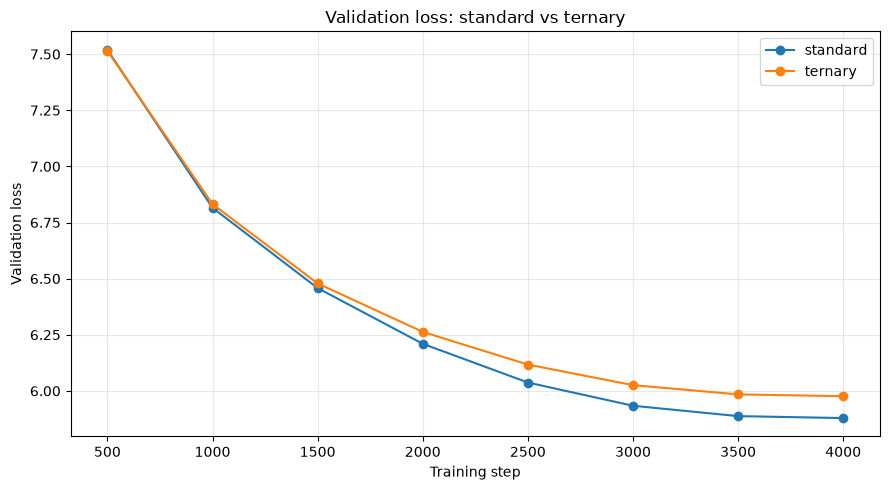

In [17]:
history = pd.concat(
    [standard_history, ternary_history],
    ignore_index=True,
)
history.to_csv(Path(cfg.output_dir) / "training_history.csv", index=False)
display(history)

fig, ax = plt.subplots(figsize=(9, 5))
for model_name, group in history.groupby("model"):
    ax.plot(group["step"], group["val_loss"], marker="o", label=model_name)
ax.set_xlabel("Training step")
ax.set_ylabel("Validation loss")
ax.set_title("Validation loss: standard vs ternary")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
quality_comparison = pd.DataFrame(
    [standard_metrics, ternary_metrics]
)[
    [
        "model",
        "val_loss",
        "perplexity",
        "token_accuracy",
        "training_seconds",
        "overall_train_tokens_per_second",
        "training_steps",
    ]
].sort_values("val_loss")

display(quality_comparison)
quality_comparison.to_csv(
    Path(cfg.output_dir) / "quality_comparison.csv",
    index=False,
)

,model,val_loss,perplexity,token_accuracy,training_seconds,overall_train_tokens_per_second,training_steps
0,standard,5.878852,357.398851,0.188561,165.152648,74403.893443,4000
1,ternary,5.976268,393.967369,0.175553,166.622122,73747.710578,4000


## 13. Deployment: зачем отдельные модели

QAT-модель специально неудобна для inference: `TernaryLinear.forward()` каждый раз
повторяет `abs → mean → round → clamp`. После обучения эти операции больше не нужны.

Ниже строятся:

1. `FrozenTernaryLinear` — один раз материализует тернарные веса; это быстрый baseline;
2. `PackedTernaryLinear` — хранит только packed 2-bit codes + один scale на output-channel;
3. TorchAO `torch.int2` backend — применяется **только** к слоям, происходящим из
   `TernaryLinear`.

Кодирование exact packed2:

| Тернарный вес | 2-bit код |
|---:|---:|
| -1 | `00` |
| 0 | `01` |
| +1 | `10` |
| reserved | `11` |

Таким образом, четыре веса занимают ровно один байт.


In [19]:
def resolve_dtype(name: str) -> torch.dtype:
    mapping = {
        "float16": torch.float16,
        "bfloat16": torch.bfloat16,
        "float32": torch.float32,
    }
    try:
        return mapping[name]
    except KeyError as exc:
        raise ValueError(f"Unsupported dtype name: {name}") from exc


PACKED_SCALE_DTYPE = resolve_dtype(cfg.packed_scale_dtype)
TORCHAO_SCALE_DTYPE = resolve_dtype(cfg.torchao_scale_dtype)


def pack_ternary_codes_2bit(codes: torch.Tensor) -> torch.Tensor:
    """
    Pack {-1, 0, +1} into uint8, four logical weights per byte.

    Encoding:
        -1 -> 0
         0 -> 1
        +1 -> 2
         3 is reserved
    """
    if codes.ndim != 2:
        raise ValueError(f"Expected 2-D codes, got {tuple(codes.shape)}")

    if not torch.all((codes >= -1) & (codes <= 1)):
        raise ValueError("Ternary codes must be in {-1, 0, +1}")

    encoded = (codes.to(torch.int16) + 1).to(torch.uint8)
    out_features, in_features = encoded.shape

    pad = (-in_features) % 4
    if pad:
        # zero weight encodes as 1
        encoded = F.pad(encoded, (0, pad), value=1)

    groups = encoded.view(out_features, -1, 4).to(torch.int32)

    packed = (
        groups[..., 0]
        | (groups[..., 1] << 2)
        | (groups[..., 2] << 4)
        | (groups[..., 3] << 6)
    )
    return packed.to(torch.uint8).contiguous()


def unpack_ternary_codes_2bit(
    packed: torch.Tensor,
    in_features: int,
    dtype: torch.dtype,
) -> torch.Tensor:
    """
    Bitwise reference decoder. No floating full-precision weight is stored.
    """
    raw = packed.to(torch.int32)
    c0 = raw & 0b11
    c1 = (raw >> 2) & 0b11
    c2 = (raw >> 4) & 0b11
    c3 = (raw >> 6) & 0b11

    encoded = torch.stack((c0, c1, c2, c3), dim=-1)
    encoded = encoded.reshape(packed.size(0), -1)[:, :in_features]

    # 0,1,2 -> -1,0,+1.
    # Reserved code 3 is excluded by the export/roundtrip validation.
    # No data-dependent Python branch here: this keeps the function friendly
    # to torch.compile and avoids a CUDA synchronization in every forward.
    return (encoded.to(dtype) - 1)


def packed_roundtrip_test() -> None:
    test_codes = torch.tensor(
        [
            [-1, 0, 1, -1, 1, 0, 0],
            [1, 1, 0, -1, -1, 0, 1],
        ],
        dtype=torch.float32,
    )
    packed = pack_ternary_codes_2bit(test_codes)
    restored = unpack_ternary_codes_2bit(
        packed,
        in_features=test_codes.size(1),
        dtype=torch.float32,
    )
    torch.testing.assert_close(restored, test_codes, rtol=0, atol=0)

    logical_bits = test_codes.numel() * 2
    physical_bits = packed.numel() * 8
    print(
        "2-bit pack/unpack OK:",
        f"logical={logical_bits} bits, stored={physical_bits} bits "
        "(difference is only row-end padding)",
    )


packed_roundtrip_test()


2-bit pack/unpack OK: logical=28 bits, stored=32 bits (difference is only row-end padding)


In [20]:
class FrozenTernaryLinear(nn.Linear):
    """
    Inference-only baseline.

    The ternary projection is computed once at export. Forward is then a plain
    nn.Linear with fixed floating-point ternary-valued weights.

    This is expected to be much faster than QAT fake quantization, but it is
    NOT a 2-bit storage format.
    """

    is_ternary_deploy = True

    @classmethod
    @torch.no_grad()
    def from_qat(cls, module: TernaryLinear) -> "FrozenTernaryLinear":
        result = cls(
            module.in_features,
            module.out_features,
            bias=module.bias is not None,
            device=module.weight.device,
            dtype=module.weight.dtype,
        )
        quantized_weight, _ = ternary_quantize_per_output_channel(module.weight)
        result.weight.copy_(quantized_weight)

        if module.bias is not None:
            result.bias.copy_(module.bias)

        result.weight.requires_grad_(False)
        if result.bias is not None:
            result.bias.requires_grad_(False)

        return result


def _resolve_custom_packed2_op():
    """
    Resolve the future fused operator once, not on every forward.

    Expected signature:
        torch.ops.ternary_ops.linear_packed2(
            x, packed_weight, scale, bias, in_features
        )
    """
    try:
        return torch.ops.ternary_ops.linear_packed2.default
    except Exception:
        return None


CUSTOM_PACKED2_OP = _resolve_custom_packed2_op()


class PackedTernaryLinear(nn.Module):
    """
    Exact 2-bit storage for ternary weights.

    Persistent state:
        packed_weight : uint8, 4 weights/byte
        scale         : one FP16/BF16/FP32 value per output channel
        bias          : optional floating buffer

    There is NO floating master weight parameter for this layer.
    """

    is_ternary_deploy = True

    def __init__(
        self,
        in_features: int,
        out_features: int,
        bias: bool = False,
        *,
        scale_dtype: torch.dtype = torch.float16,
        use_custom_kernel: bool = True,
    ) -> None:
        super().__init__()
        self.in_features = int(in_features)
        self.out_features = int(out_features)
        self.use_custom_kernel = bool(use_custom_kernel)

        packed_cols = math.ceil(self.in_features / 4)
        self.register_buffer(
            "packed_weight",
            torch.full(
                (self.out_features, packed_cols),
                fill_value=0b01010101,  # four encoded zeros
                dtype=torch.uint8,
            ),
        )
        self.register_buffer(
            "scale",
            torch.ones(
                (self.out_features, 1),
                dtype=scale_dtype,
            ),
        )

        if bias:
            self.register_buffer(
                "bias",
                torch.zeros(self.out_features, dtype=scale_dtype),
            )
        else:
            self.register_buffer("bias", None)

    @classmethod
    @torch.no_grad()
    def from_qat(
        cls,
        module: TernaryLinear,
        *,
        scale_dtype: torch.dtype = torch.float16,
        use_custom_kernel: bool = True,
    ) -> "PackedTernaryLinear":
        codes, scale = ternary_codes_and_scale(module.weight)

        result = cls(
            module.in_features,
            module.out_features,
            bias=module.bias is not None,
            scale_dtype=scale_dtype,
            use_custom_kernel=use_custom_kernel,
        )
        result.packed_weight.copy_(
            pack_ternary_codes_2bit(codes).to(result.packed_weight.device)
        )
        result.scale.copy_(scale.to(dtype=scale_dtype, device=result.scale.device))

        if module.bias is not None:
            result.bias.copy_(
                module.bias.detach().to(dtype=scale_dtype, device=result.bias.device)
            )

        return result

    def _reference_forward(self, x: torch.Tensor) -> torch.Tensor:
        codes = unpack_ternary_codes_2bit(
            self.packed_weight,
            in_features=self.in_features,
            dtype=x.dtype,
        )
        weight = codes * self.scale.to(dtype=x.dtype)
        bias = None if self.bias is None else self.bias.to(dtype=x.dtype)
        return F.linear(x, weight, bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.use_custom_kernel and CUSTOM_PACKED2_OP is not None:
            return CUSTOM_PACKED2_OP(
                x,
                self.packed_weight,
                self.scale,
                self.bias,
                self.in_features,
            )

        # Reference path already uses bitwise unpacking, but materializes the
        # floating matrix before GEMM. Replace this path with a fused kernel
        # to obtain both low memory traffic and high speed.
        return self._reference_forward(x)

    def extra_repr(self) -> str:
        return (
            f"in_features={self.in_features}, "
            f"out_features={self.out_features}, "
            f"2bit=True, custom_kernel={self.use_custom_kernel}"
        )


In [21]:
def clone_trained_ternary_to_cpu(model: nn.Module) -> DecoderOnlyTransformer:
    """
    Rebuild an uncompiled QAT model on CPU and load the trained state.
    This avoids deepcopying a potentially compiled/CUDA graph.
    """
    clone = DecoderOnlyTransformer(model_cfg, linear_cls=TernaryLinear)
    clone.load_state_dict(clone_state_dict_to_cpu(model), strict=True)
    clone.eval()
    return clone


def replace_ternary_linears_(
    parent: nn.Module,
    factory: Callable[[TernaryLinear], nn.Module],
) -> nn.Module:
    for name, child in list(parent.named_children()):
        if isinstance(child, TernaryLinear):
            setattr(parent, name, factory(child))
        else:
            replace_ternary_linears_(child, factory)
    return parent


@torch.no_grad()
def build_frozen_ternary_model(model: nn.Module) -> nn.Module:
    result = clone_trained_ternary_to_cpu(model)
    replace_ternary_linears_(result, FrozenTernaryLinear.from_qat)
    return result.eval()


@torch.no_grad()
def build_packed2_ternary_model(model: nn.Module) -> nn.Module:
    result = clone_trained_ternary_to_cpu(model)

    def factory(layer: TernaryLinear) -> PackedTernaryLinear:
        return PackedTernaryLinear.from_qat(
            layer,
            scale_dtype=PACKED_SCALE_DTYPE,
            use_custom_kernel=cfg.prefer_custom_packed_kernel,
        )

    replace_ternary_linears_(result, factory)
    return result.eval()


frozen_ternary_model = build_frozen_ternary_model(ternary_model)
packed2_ternary_model = build_packed2_ternary_model(ternary_model)

print(
    "Frozen ternary layers:",
    sum(isinstance(m, FrozenTernaryLinear) for m in frozen_ternary_model.modules()),
)
print(
    "Packed 2-bit ternary layers:",
    sum(isinstance(m, PackedTernaryLinear) for m in packed2_ternary_model.modules()),
)


Frozen ternary layers: 72
Packed 2-bit ternary layers: 72


### TorchAO `torch.int2` backend

Используется только как дополнительный inference backend.

**Почему не считаем его доказательством 2-bit storage:** текущий stable
`IntxWeightOnlyConfig(version=2)` поддерживает `torch.int2`, но weight-only реализация
использует `IntxUnpackedToInt8Tensor`. Поэтому реальный размер обязательно измеряется
отдельно, а exact 2-bit артефактом считается `PackedTernaryLinear`.

Фильтр `isinstance(module, FrozenTernaryLinear)` гарантирует, что embedding, LM-head,
LayerNorm и обычные `nn.Linear` не затрагиваются.


In [22]:
@torch.no_grad()
def build_torchao_int2_model(
    model: nn.Module,
) -> tuple[Optional[nn.Module], Optional[str]]:
    if not cfg.enable_torchao_int2_backend:
        return None, "disabled by config"

    if not TORCHAO_AVAILABLE:
        return None, f"TorchAO unavailable: {TORCHAO_IMPORT_ERROR}"

    if not hasattr(torch, "int2"):
        return None, (
            "This PyTorch build has no torch.int2 dtype. "
            "Upgrade PyTorch/TorchAO together."
        )

    result = build_frozen_ternary_model(model)

    mapping_type = getattr(
        MappingType,
        "SYMMETRIC_NO_CLIPPING_ERR",
        MappingType.SYMMETRIC,
    )

    int2_config = IntxWeightOnlyConfig(
        weight_dtype=torch.int2,
        granularity=PerAxis(0),
        mapping_type=mapping_type,
        scale_dtype=TORCHAO_SCALE_DTYPE,
    )

    def only_ternary_deploy_layers(module: nn.Module, fqn: str) -> bool:
        return isinstance(module, FrozenTernaryLinear)

    try:
        quantize_(
            result,
            int2_config,
            filter_fn=only_ternary_deploy_layers,
            device=device,
        )
    except Exception as exc:
        return None, f"TorchAO int2 conversion failed: {type(exc).__name__}: {exc}"

    result.eval()
    return result, None


torchao_int2_model, torchao_int2_error = build_torchao_int2_model(ternary_model)

if torchao_int2_model is None:
    print("TorchAO int2 backend skipped:", torchao_int2_error)
else:
    print("TorchAO int2 backend built successfully.")

    rows = []
    for name, module in torchao_int2_model.named_modules():
        if isinstance(module, FrozenTernaryLinear):
            rows.append(
                {
                    "layer": name,
                    "weight_python_type": type(module.weight).__name__,
                    "logical_dtype": str(module.weight.dtype),
                    "shape": tuple(module.weight.shape),
                }
            )
    display(pd.DataFrame(rows).head(20))


TorchAO int2 backend built successfully.


,layer,weight_python_type,logical_dtype,shape
0,blocks.0.attn.q_proj,IntxUnpackedToInt8Tensor,torch.float32,"(256, 256)"
1,blocks.0.attn.k_proj,IntxUnpackedToInt8Tensor,torch.float32,"(256, 256)"
2,blocks.0.attn.v_proj,IntxUnpackedToInt8Tensor,torch.float32,"(256, 256)"
3,blocks.0.attn.out_proj,IntxUnpackedToInt8Tensor,torch.float32,"(256, 256)"
4,blocks.0.ffn.0,IntxUnpackedToInt8Tensor,torch.float32,"(1024, 256)"
5,blocks.0.ffn.2,IntxUnpackedToInt8Tensor,torch.float32,"(256, 1024)"
6,blocks.1.attn.q_proj,IntxUnpackedToInt8Tensor,torch.float32,"(256, 256)"
7,blocks.1.attn.k_proj,IntxUnpackedToInt8Tensor,torch.float32,"(256, 256)"
8,blocks.1.attn.v_proj,IntxUnpackedToInt8Tensor,torch.float32,"(256, 256)"
9,blocks.1.attn.out_proj,IntxUnpackedToInt8Tensor,torch.float32,"(256, 256)"


## 14. Проверка численной эквивалентности deployment-моделей

`frozen` должен совпадать с QAT inference практически точно, потому что в `eval()` QAT
использует те же тернарные значения.

`packed2` может иметь небольшую погрешность из-за хранения scale в FP16/BF16.
Перед speed benchmark проверяем logits на одном батче.


In [ ]:
@torch.inference_mode()
def compare_logits(
    reference: nn.Module,
    candidate: nn.Module,
    input_ids: torch.Tensor,
    candidate_name: str,
) -> dict[str, float]:
    reference = reference.to(device).eval()
    candidate = candidate.to(device).eval()
    input_ids = input_ids.to(device)

    # Для этой проверки отключаем autocast, чтобы измерять именно ошибку export.
    ref_logits = reference(input_ids).float()
    cand_logits = candidate(input_ids).float()

    diff = (ref_logits - cand_logits).abs()
    return {
        "model": candidate_name,
        "max_abs_logit_error": diff.max().item(),
        "mean_abs_logit_error": diff.mean().item(),
        "same_argmax_fraction": (
            ref_logits.argmax(dim=-1) == cand_logits.argmax(dim=-1)
        ).float().mean().item(),
    }


_, benchmark_loader = make_dataloaders(cfg.seed)
benchmark_batch = next(iter(benchmark_loader))["input_ids"][:2]

equivalence_rows = [
    compare_logits(
        ternary_model,
        frozen_ternary_model,
        benchmark_batch,
        "ternary_frozen",
    ),
    compare_logits(
        ternary_model,
        packed2_ternary_model,
        benchmark_batch,
        "ternary_packed2",
    ),
]

if torchao_int2_model is not None:
    equivalence_rows.append(
        compare_logits(
            ternary_model,
            torchao_int2_model,
            benchmark_batch,
            "ternary_torchao_int2",
        )
    )

deployment_equivalence = pd.DataFrame(equivalence_rows)
display(deployment_equivalence)
deployment_equivalence.to_csv(
    Path(cfg.output_dir) / "deployment_equivalence.csv",
    index=False,
)


,model,max_abs_logit_error,mean_abs_logit_error,same_argmax_fraction
0,ternary_frozen,0.002334,0.000114,1.0
1,ternary_packed2,0.002334,0.000114,1.0
2,ternary_torchao_int2,0.002334,0.000114,1.0


## 15. Фактический размер: exact packed2, а не теоретическая оценка

Для `PackedTernaryLinear` считаем **реальные persistent tensors**:

- `packed_weight`: `uint8`, четыре логических веса на байт;
- `scale`: один FP16/BF16/FP32 scale на output-channel;
- bias, если он есть.

Остальные слои модели остаются в исходном формате и не подвергаются integer quantization.

Дополнительно сохраняем deployment checkpoint и измеряем его реальный размер на диске.


In [24]:
def unique_plain_tensor_storage_bytes(model: nn.Module) -> int:
    """
    Exact for ordinary Tensor/Parameter/buffer storage.
    Tensor subclasses from TorchAO are reported separately via serialized size.
    """
    seen = set()
    total = 0

    tensors = list(model.parameters()) + list(model.buffers())
    for tensor in tensors:
        if tensor is None:
            continue

        try:
            storage = tensor.untyped_storage()
            key = (storage.data_ptr(), storage.nbytes(), str(tensor.device))
            nbytes = storage.nbytes()
        except Exception:
            key = id(tensor)
            nbytes = tensor.numel() * tensor.element_size()

        if key in seen:
            continue
        seen.add(key)
        total += nbytes

    return total


def packed2_layer_storage_stats(model: nn.Module) -> dict[str, int]:
    logical_weights = 0
    packed_bytes = 0
    scale_bytes = 0
    bias_bytes = 0

    for module in model.modules():
        if not isinstance(module, PackedTernaryLinear):
            continue

        logical_weights += module.in_features * module.out_features
        packed_bytes += module.packed_weight.numel() * module.packed_weight.element_size()
        scale_bytes += module.scale.numel() * module.scale.element_size()

        if module.bias is not None:
            bias_bytes += module.bias.numel() * module.bias.element_size()

    theoretical_min_bytes = math.ceil(logical_weights * 2 / 8)

    return {
        "ternary_logical_weights": logical_weights,
        "theoretical_2bit_bytes": theoretical_min_bytes,
        "actual_packed_code_bytes": packed_bytes,
        "scale_bytes": scale_bytes,
        "bias_bytes": bias_bytes,
        "ternary_deploy_bytes": packed_bytes + scale_bytes + bias_bytes,
    }


def save_state_dict_and_measure(
    model: nn.Module,
    filename: str,
) -> tuple[Path, int]:
    path = Path(cfg.output_dir) / filename

    # state_dict tensors are moved to CPU without changing dtype/packing.
    state = {}
    for key, value in model.state_dict().items():
        try:
            state[key] = value.detach().cpu()
        except Exception:
            state[key] = value

    torch.save(state, path)
    return path, path.stat().st_size


packed2_cpu = packed2_ternary_model.cpu().eval()
packed_stats = packed2_layer_storage_stats(packed2_cpu)

packed_ckpt_path, packed_ckpt_bytes = save_state_dict_and_measure(
    packed2_cpu,
    "ternary_packed2bit_state_dict.pt",
)

storage_rows = [
    {
        "model": "standard",
        "in_memory_storage_mb": unique_plain_tensor_storage_bytes(
            standard_model
        ) / 1024**2,
        "serialized_state_dict_mb": np.nan,
    },
    {
        "model": "ternary_qat_fake",
        "in_memory_storage_mb": unique_plain_tensor_storage_bytes(
            ternary_model
        ) / 1024**2,
        "serialized_state_dict_mb": np.nan,
    },
    {
        "model": "ternary_frozen",
        "in_memory_storage_mb": unique_plain_tensor_storage_bytes(
            frozen_ternary_model
        ) / 1024**2,
        "serialized_state_dict_mb": np.nan,
    },
    {
        "model": "ternary_packed2",
        "in_memory_storage_mb": unique_plain_tensor_storage_bytes(
            packed2_cpu
        ) / 1024**2,
        "serialized_state_dict_mb": packed_ckpt_bytes / 1024**2,
    },
]

if torchao_int2_model is not None:
    try:
        torchao_path, torchao_bytes = save_state_dict_and_measure(
            torchao_int2_model,
            "ternary_torchao_int2_state_dict.pt",
        )
        storage_rows.append(
            {
                "model": "ternary_torchao_int2",
                "in_memory_storage_mb": np.nan,
                "serialized_state_dict_mb": torchao_bytes / 1024**2,
            }
        )
    except Exception as exc:
        print("Could not serialize TorchAO int2 model:", exc)

storage_comparison = pd.DataFrame(storage_rows)
display(storage_comparison)

print("\nExact packed ternary-layer storage:")
for key, value in packed_stats.items():
    print(f"  {key}: {value:,}")

overhead = (
    packed_stats["actual_packed_code_bytes"]
    - packed_stats["theoretical_2bit_bytes"]
)
print(
    f"\nRow-padding overhead in packed codes: {overhead:,} bytes"
)
print(f"Packed checkpoint: {packed_ckpt_path.resolve()}")

storage_comparison.to_csv(
    Path(cfg.output_dir) / "storage_comparison.csv",
    index=False,
)


,model,in_memory_storage_mb,serialized_state_dict_mb
0,standard,85.611328,NaN
1,ternary_qat_fake,85.611328,NaN
2,ternary_frozen,85.611328,NaN
3,ternary_packed2,51.914062,51.975726
4,ternary_torchao_int2,NaN,108.018842



Exact packed ternary-layer storage:
  ternary_logical_weights: 9,437,184
  theoretical_2bit_bytes: 2,359,296
  actual_packed_code_bytes: 2,359,296
  scale_bytes: 55,296
  bias_bytes: 0
  ternary_deploy_bytes: 2,414,592

Row-padding overhead in packed codes: 0 bytes
Packed checkpoint: /home/phil/GitHub/llm/transformer_benchmark_outputs/ternary_packed2bit_state_dict.pt


## 16. Speed benchmark: QAT vs frozen vs packed2 vs TorchAO int2

Здесь важно разделять две причины ускорения:

- `ternary_qat_fake → ternary_frozen`: исчезает повторная квантизация каждого forward;
- `ternary_frozen → ternary_packed2`: storage уменьшается, но reference backend должен
  распаковать матрицу. Без fused kernel этот вариант может быть **медленнее**;
- `torch.compile` применяется после export, то есть компилируется уже inference graph.

Если появится `torch.ops.ternary_ops.linear_packed2`, тот же packed checkpoint сможет
использовать fused kernel без изменения формата весов.


In [25]:
def synchronize_device() -> None:
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def maybe_compile_inference(
    model: nn.Module,
    name: str,
) -> tuple[nn.Module, bool, Optional[str]]:
    model = model.to(device).eval()

    if not cfg.compile_inference_models:
        return model, False, None

    if not hasattr(torch, "compile"):
        return model, False, "torch.compile unavailable"

    try:
        compiled = torch.compile(
            model,
            mode=cfg.compile_mode,
            fullgraph=False,
        )
        return compiled, True, None
    except Exception as exc:
        return model, False, f"{type(exc).__name__}: {exc}"


@torch.inference_mode()
def benchmark_forward(
    model: nn.Module,
    input_ids: torch.Tensor,
    model_name: str,
    compiled: bool,
) -> dict[str, float]:
    model.eval()
    input_ids = input_ids.to(device)

    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    for _ in range(cfg.benchmark_warmup):
        with autocast_context():
            _ = model(input_ids)

    synchronize_device()

    timings_ms = []
    for _ in range(cfg.benchmark_repeats):
        synchronize_device()
        started = time.perf_counter()

        with autocast_context():
            _ = model(input_ids)

        synchronize_device()
        timings_ms.append((time.perf_counter() - started) * 1_000.0)

    mean_ms = statistics.mean(timings_ms)
    median_ms = statistics.median(timings_ms)
    p95_ms = float(np.percentile(timings_ms, 95))
    tokens_per_batch = input_ids.numel()

    result = {
        "model": model_name,
        "device": str(device),
        "compiled": compiled,
        "batch_size": input_ids.size(0),
        "sequence_length": input_ids.size(1),
        "mean_latency_ms": mean_ms,
        "median_latency_ms": median_ms,
        "p95_latency_ms": p95_ms,
        "tokens_per_second": tokens_per_batch / (mean_ms / 1_000.0),
    }

    if device.type == "cuda":
        result["peak_cuda_memory_mb"] = (
            torch.cuda.max_memory_allocated() / 1024**2
        )
    else:
        result["peak_cuda_memory_mb"] = float("nan")

    return result


# packed2 был временно перенесён на CPU для сериализации.
packed2_ternary_model = packed2_ternary_model.to(device)

candidate_models = [
    ("standard", standard_model),
    ("ternary_qat_fake", ternary_model),
    ("ternary_frozen", frozen_ternary_model),
    ("ternary_packed2", packed2_ternary_model),
]

if torchao_int2_model is not None:
    candidate_models.append(("ternary_torchao_int2", torchao_int2_model))

benchmark_rows = []
compile_rows = []

for name, model in candidate_models:
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

    inference_model, compiled, compile_error = maybe_compile_inference(model, name)

    compile_rows.append(
        {
            "model": name,
            "compiled": compiled,
            "compile_error": compile_error,
        }
    )

    try:
        benchmark_rows.append(
            benchmark_forward(
                inference_model,
                benchmark_batch,
                model_name=name,
                compiled=compiled,
            )
        )
    except Exception as exc:
        benchmark_rows.append(
            {
                "model": name,
                "device": str(device),
                "compiled": compiled,
                "batch_size": benchmark_batch.size(0),
                "sequence_length": benchmark_batch.size(1),
                "mean_latency_ms": np.nan,
                "median_latency_ms": np.nan,
                "p95_latency_ms": np.nan,
                "tokens_per_second": np.nan,
                "peak_cuda_memory_mb": np.nan,
                "benchmark_error": f"{type(exc).__name__}: {exc}",
            }
        )

forward_results = pd.DataFrame(benchmark_rows)
compile_results = pd.DataFrame(compile_rows)

display(forward_results)
display(compile_results)

forward_results.to_csv(
    Path(cfg.output_dir) / "forward_benchmark.csv",
    index=False,
)
compile_results.to_csv(
    Path(cfg.output_dir) / "compile_results.csv",
    index=False,
)


W0807 13:41:53.828000 19584 torch/_inductor/utils.py:1953] [0/4] Not enough SMs to use max_autotune_gemm mode
W0807 13:42:18.920000 19584 torch/_dynamo/convert_frame.py:1994] [0/8] torch._dynamo hit config.recompile_limit (8)
W0807 13:42:18.920000 19584 torch/_dynamo/convert_frame.py:1994] [0/8]    function: 'forward' (/tmp/ipykernel_19584/868271859.py:114)
W0807 13:42:18.920000 19584 torch/_dynamo/convert_frame.py:1994] [0/8]    last reason: 0/7: ___check_type_id(self._modules['blocks']._modules['0']._modules['ffn']._modules['0'], 774824992), type=<class '__main__.PackedTernaryLinear'>  # input = module(input)  # nn/modules/container.py:253 in forward (HINT: type PackedTernaryLinear)
W0807 13:42:18.920000 19584 torch/_dynamo/convert_frame.py:1994] [0/8] User stack trace:
W0807 13:42:18.920000 19584 torch/_dynamo/convert_frame.py:1994] [0/8]   File "/tmp/ipykernel_19584/868271859.py", line 126, in forward
W0807 13:42:18.920000 19584 torch/_dynamo/convert_frame.py:1994] [0/8]     x = bl

,model,device,compiled,batch_size,sequence_length,mean_latency_ms,median_latency_ms,p95_latency_ms,tokens_per_second,peak_cuda_memory_mb
0,standard,cuda,True,2,384,2.235335,2.219980,2.313022,343572.631328,530.261719
1,ternary_qat_fake,cuda,True,2,384,2.245683,2.233222,2.305097,341989.515453,530.261719
2,ternary_frozen,cuda,True,2,384,2.236916,2.222434,2.301496,343329.908138,530.261719
3,ternary_packed2,cuda,True,2,384,2.191388,2.164361,2.247184,350462.763717,530.261719
4,ternary_torchao_int2,cuda,True,2,384,4.994347,4.990108,5.098009,153773.859493,531.014648


,model,compiled,compile_error
0,standard,True,None
1,ternary_qat_fake,True,None
2,ternary_frozen,True,None
3,ternary_packed2,True,None
4,ternary_torchao_int2,True,None


## 17. Проверка, что packed-модель действительно не хранит float weight в тернарных слоях


In [26]:
packed_layer_rows = []

for name, module in packed2_ternary_model.named_modules():
    if not isinstance(module, PackedTernaryLinear):
        continue

    packed_layer_rows.append(
        {
            "layer": name,
            "in_features": module.in_features,
            "out_features": module.out_features,
            "logical_weights": module.in_features * module.out_features,
            "packed_weight_shape": tuple(module.packed_weight.shape),
            "packed_dtype": str(module.packed_weight.dtype),
            "packed_bytes": (
                module.packed_weight.numel()
                * module.packed_weight.element_size()
            ),
            "scale_dtype": str(module.scale.dtype),
            "has_float_weight_parameter": hasattr(module, "weight"),
        }
    )

packed_layer_report = pd.DataFrame(packed_layer_rows)
display(packed_layer_report)

if packed_layer_report["has_float_weight_parameter"].any():
    raise RuntimeError(
        "PackedTernaryLinear unexpectedly contains floating weight parameters."
    )

packed_layer_report.to_csv(
    Path(cfg.output_dir) / "packed2_layer_report.csv",
    index=False,
)


,layer,in_features,out_features,logical_weights,packed_weight_shape,packed_dtype,packed_bytes,scale_dtype,has_float_weight_parameter
0,blocks.0.attn.q_proj,256,256,65536,"(256, 64)",torch.uint8,16384,torch.float16,False
1,blocks.0.attn.k_proj,256,256,65536,"(256, 64)",torch.uint8,16384,torch.float16,False
2,blocks.0.attn.v_proj,256,256,65536,"(256, 64)",torch.uint8,16384,torch.float16,False
3,blocks.0.attn.out_proj,256,256,65536,"(256, 64)",torch.uint8,16384,torch.float16,False
4,blocks.0.ffn.0,256,1024,262144,"(1024, 64)",torch.uint8,65536,torch.float16,False
...,...,...,...,...,...,...,...,...,...
67,blocks.11.attn.k_proj,256,256,65536,"(256, 64)",torch.uint8,16384,torch.float16,False
68,blocks.11.attn.v_proj,256,256,65536,"(256, 64)",torch.uint8,16384,torch.float16,False
69,blocks.11.attn.out_proj,256,256,65536,"(256, 64)",torch.uint8,16384,torch.float16,False
70,blocks.11.ffn.0,256,1024,262144,"(1024, 64)",torch.uint8,65536,torch.float16,False


## 18. Что нужно для настоящего bitwise/fused matmul

Текущий `PackedTernaryLinear` уже даёт корректный ABI хранения:

```text
packed_weight : uint8 [out_features, ceil(in_features / 4)]
scale         : fp16/bf16/fp32 [out_features, 1]
```

Следующий шаг — реализовать оператор:

```python
torch.ops.ternary_ops.linear_packed2(
    x,
    packed_weight,
    scale,
    bias,
    in_features,
)
```

в Triton/CUDA/C++.

Он должен:

1. читать packed байты;
2. извлекать 2-bit codes непосредственно внутри kernel;
3. преобразовывать `00/01/10` в `-1/0/+1`;
4. выполнять accumulation **без создания полной float-матрицы весов**;
5. умножать результат каждого output-channel на `scale`.

### Важно про «чисто битовые операции»

При FP16/BF16 activations произведение `activation × {-1,0,+1}` можно заменить
на `-x`, `0`, `+x`, то есть на выбор знака/пропуск и суммирование, но accumulation
остаётся числовым.

Чтобы получить классический XNOR/popcount-style **полностью bitwise dot product**,
нужно дополнительно квантизовать activations до binary/ternary representation.
Это отдельный эксперимент и он меняет модель сильнее, чем weight-only ternarization.


## 19. Генерация текста

Сравниваем обычную, QAT-тернарную и exact packed2 deployment-модель.


In [36]:
@torch.inference_mode()
def generate_text(
    model: nn.Module,
    prompt: str,
    max_new_tokens: int = 80,
    temperature: float = 0.8,
    top_k: Optional[int] = 50,
) -> str:
    if temperature <= 0:
        raise ValueError("temperature должна быть больше нуля")

    model.eval()
    encoded = tokenizer(
        prompt,
        add_special_tokens=False,
        return_tensors="pt",
    )["input_ids"].to(device)

    if encoded.size(1) == 0:
        encoded = torch.tensor(
            [[tokenizer.eos_token_id]],
            dtype=torch.long,
            device=device,
        )

    generated = encoded

    for _ in range(max_new_tokens):
        model_input = generated[:, -cfg.sequence_length:]
        with autocast_context():
            logits = model(model_input)[:, -1, :].float()

        logits = logits / temperature
        if top_k is not None:
            k = min(top_k, logits.size(-1))
            threshold = torch.topk(logits, k=k, dim=-1).values[:, -1:]
            logits = logits.masked_fill(logits < threshold, float("-inf"))

        probabilities = F.softmax(logits, dim=-1)
        next_token = torch.multinomial(probabilities, num_samples=1)
        generated = torch.cat([generated, next_token], dim=1)

        if next_token.item() == tokenizer.eos_token_id:
            break

    return tokenizer.decode(generated[0].tolist(), skip_special_tokens=True)


prompt = "Вопрос:\nЧто такое машинное обучение?\n\nОтвет:\n"

# prompt = "Привет как дела?"

In [37]:
seed_everything(cfg.seed)
print("STANDARD:\n", generate_text(standard_model, prompt))


STANDARD:
 Вопрос:
Что такое машинное обучение?

Ответ:

Привет, я может быть более чем-то с которыми есть все раз. Я можешь узнать он нужно получить с различными и ли вы не нужно отметить, что я я не вы будете быть много, что только мы бы вы будете помочь мне нужно понять, что вы можете сделать.

#### У нас есть

1. **Али:** - Ты


In [38]:
seed_everything(cfg.seed)
print("\nTERNARY QAT:\n", generate_text(ternary_model, prompt))



TERNARY QAT:
 Вопрос:
Что такое машинное обучение?

Ответ:

Привет?

ИЯ я бы бы не нравится есть все раз?


1. **:**:** - я должен использовать, это есть, как я не вы **:**
2.**:**
2. **:**

2.** **:
1. **:**:**:
3.**: Ты


In [39]:
seed_everything(cfg.seed)
print("\nTERNARY PACKED 2-BIT:\n", generate_text(packed2_ternary_model, prompt))



TERNARY PACKED 2-BIT:
 Вопрос:
Что такое машинное обучение?

Ответ:

Привет?

ИЯ я бы бы не нравится есть все раз?


1. **:**:** - я должен использовать, это есть, как я не вы **:**
2.**:**
2. **:**

2.** **:
1. **:**:**:
3.**: Ты


## 20. Объединённое резюме эксперимента


In [31]:
quality_for_summary = quality_comparison.copy()

# Deployment variants inherit ternary quality; exact export error is reported separately.
deployment_quality_rows = []
ternary_quality = quality_for_summary[
    quality_for_summary["model"] == "ternary"
].iloc[0].to_dict()

for deployment_name in [
    "ternary_qat_fake",
    "ternary_frozen",
    "ternary_packed2",
    "ternary_torchao_int2",
]:
    if deployment_name not in set(forward_results["model"]):
        continue

    row = dict(ternary_quality)
    row["model"] = deployment_name
    deployment_quality_rows.append(row)

quality_expanded = pd.concat(
    [
        quality_for_summary[
            quality_for_summary["model"] == "standard"
        ],
        pd.DataFrame(deployment_quality_rows),
    ],
    ignore_index=True,
)

summary = (
    quality_expanded
    .merge(forward_results, on="model", how="left")
    .merge(storage_comparison, on="model", how="left")
    .merge(deployment_equivalence, on="model", how="left")
)

display(summary)
summary.to_csv(
    Path(cfg.output_dir) / "experiment_summary.csv",
    index=False,
)

print(f"Все результаты сохранены в: {Path(cfg.output_dir).resolve()}")
print(
    "Exact packed2 checkpoint:",
    (Path(cfg.output_dir) / "ternary_packed2bit_state_dict.pt").resolve(),
)


,model,val_loss,perplexity,token_accuracy,training_seconds,overall_train_tokens_per_second,training_steps,device,compiled,batch_size,...,mean_latency_ms,median_latency_ms,p95_latency_ms,tokens_per_second,peak_cuda_memory_mb,in_memory_storage_mb,serialized_state_dict_mb,max_abs_logit_error,mean_abs_logit_error,same_argmax_fraction
0,standard,5.878852,357.398851,0.188561,165.152648,74403.893443,4000,cuda,True,2,...,2.235335,2.219980,2.313022,343572.631328,530.261719,85.611328,NaN,NaN,NaN,NaN
1,ternary_qat_fake,5.976268,393.967369,0.175553,166.622122,73747.710578,4000,cuda,True,2,...,2.245683,2.233222,2.305097,341989.515453,530.261719,85.611328,NaN,NaN,NaN,NaN
2,ternary_frozen,5.976268,393.967369,0.175553,166.622122,73747.710578,4000,cuda,True,2,...,2.236916,2.222434,2.301496,343329.908138,530.261719,85.611328,NaN,0.002334,0.000114,1.0
3,ternary_packed2,5.976268,393.967369,0.175553,166.622122,73747.710578,4000,cuda,True,2,...,2.191388,2.164361,2.247184,350462.763717,530.261719,51.914062,51.975726,0.002334,0.000114,1.0
4,ternary_torchao_int2,5.976268,393.967369,0.175553,166.622122,73747.710578,4000,cuda,True,2,...,4.994347,4.990108,5.098009,153773.859493,531.014648,NaN,108.018842,0.002334,0.000114,1.0


Все результаты сохранены в: /home/phil/GitHub/llm/transformer_benchmark_outputs
Exact packed2 checkpoint: /home/phil/GitHub/llm/transformer_benchmark_outputs/ternary_packed2bit_state_dict.pt


## Как интерпретировать результаты

1. **Качество обучения** сравнивайте по `val_loss` и `perplexity` исходных
   `standard` и `ternary`.
2. `ternary_qat_fake` нужен как контроль: он показывает стоимость fake quantization
   на каждом forward.
3. `ternary_frozen` показывает выигрыш от **удаления runtime quantization**.
4. `ternary_packed2` — это **реальный 2-bit storage** только для бывших
   `TernaryLinear`. Если reference backend медленнее frozen — это ожидаемо:
   он пока распаковывает всю матрицу перед GEMM.
5. `ternary_torchao_int2` показывает поведение текущего TorchAO Intx API,
   но его фактический serialized size нужно смотреть в `storage_comparison`.
6. Для GPU-ускорения packed2 ключевой следующий шаг — fused Triton/CUDA kernel,
   который читает `packed_weight` непосредственно.
7. Embedding, LM-head, LayerNorm и остальные нетернарные параметры здесь не
   переводятся в int2.
8. Не делайте вывод об ускорении по одному batch shape: отдельно тестируйте
   prefill (длинные последовательности) и autoregressive decode/KV-cache после
   добавления KV-cache в модель.
